# RaksaDana — Cross-Ticker Evaluation Comparison

Loads evaluation reports from BBCA, BBRI, BMRI and compares model performance side-by-side.


## Setup


In [25]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')
%matplotlib inline

cwd = Path.cwd()
ROOT        = cwd.parent if cwd.name.lower() == 'notebook' else cwd
REPORT_DIR  = ROOT / 'reports' / 'return_model'
FIGURE_DIR  = ROOT / 'outputs' / 'figures'
EVAL_DIR    = ROOT / 'outputs' / 'figures' / 'evaluation'
EVAL_DIR.mkdir(parents=True, exist_ok=True)
(ROOT / 'reports' / 'evaluation').mkdir(parents=True, exist_ok=True)

TICKERS      = ['BBCA.JK', 'BBRI.JK', 'BMRI.JK']
SAFE_TICKERS = [t.replace('.', '_') for t in TICKERS]
COLORS       = ['#D32F2F', '#2E7D32', '#F57C00']
TICKER_COLOR = dict(zip(TICKERS, COLORS))

METRIC_FORMAT = {
    'Return_MAE':         '{:.5f}',
    'Return_RMSE':        '{:.5f}',
    'Price_MAE':          '{:,.2f}',
    'Price_RMSE':         '{:,.2f}',
    'Price_MAPE':         '{:.3f}%',
    'Price_R2':           '{:.4f}',
    'Direction_Accuracy': '{:.2f}%',
}


## Load Reports


In [26]:
def load_report(safe_ticker, filename):
    path = REPORT_DIR / safe_ticker / f'return_{safe_ticker}_{filename}.csv'
    return pd.read_csv(path)

metrics_all    = pd.concat([load_report(t, 'metrics')         for t in SAFE_TICKERS], ignore_index=True)
acceptance_all = pd.concat([load_report(t, 'acceptance')      for t in SAFE_TICKERS], ignore_index=True)
walkfwd_all    = pd.concat([load_report(t, 'walk_forward')    for t in SAFE_TICKERS], ignore_index=True)
signal_all     = pd.concat([load_report(t, 'one_step_signal') for t in SAFE_TICKERS], ignore_index=True)
forecast_all   = {t: load_report(s, 'forecast_30d') for t, s in zip(TICKERS, SAFE_TICKERS)}

print('metrics shape :', metrics_all.shape)
print('models        :', metrics_all['Model'].unique().tolist())
print('tickers       :', metrics_all['Ticker'].unique().tolist())


metrics shape : (30, 10)
models        : ['Naive_Zero_Return', 'MA5_Return', 'Ridge_Return', 'LSTM_Return_Ensemble', 'LSTM_Univariate']
tickers       : ['BBCA.JK', 'BBRI.JK', 'BMRI.JK']


## LSTM Test Metrics


In [27]:
lstm_test = (
    metrics_all[
        (metrics_all['Model'] == 'LSTM_Return_Ensemble') &
        (metrics_all['Split'] == 'Test')
    ]
    .set_index('Ticker')
    [['Return_MAE', 'Return_RMSE', 'Price_MAE', 'Price_RMSE', 'Price_MAPE', 'Price_R2', 'Direction_Accuracy']]
)

display(
    lstm_test.style
    .format(METRIC_FORMAT)
    .background_gradient(subset=['Return_RMSE', 'Price_RMSE', 'Price_MAPE'], cmap='RdYlGn_r')
    .background_gradient(subset=['Price_R2', 'Direction_Accuracy'], cmap='RdYlGn')
    .set_caption('LSTM Test Metrics — All Tickers')
)


,Return_MAE,Return_RMSE,Price_MAE,Price_RMSE,Price_MAPE,Price_R2,Direction_Accuracy
Ticker,,,,,,,
BBCA.JK,0.01184,0.01593,100.70,134.00,1.183%,0.9615,49.31%
BBRI.JK,0.01531,0.02077,57.70,77.11,1.530%,0.9747,44.07%
BMRI.JK,0.01519,0.02110,72.29,99.12,1.521%,0.9746,46.14%


## Model Comparison vs Baselines


In [28]:
test_compare = (
    metrics_all[metrics_all['Split'] == 'Test']
    .set_index(['Ticker', 'Model'])
    [['Return_RMSE', 'Price_MAPE', 'Price_R2', 'Direction_Accuracy']]
    .sort_index()
)

display(
    test_compare.style
    .format({'Return_RMSE': '{:.5f}', 'Price_MAPE': '{:.3f}%',
             'Price_R2': '{:.4f}', 'Direction_Accuracy': '{:.2f}%'})
    .background_gradient(subset=['Return_RMSE', 'Price_MAPE'], cmap='RdYlGn_r')
    .background_gradient(subset=['Price_R2', 'Direction_Accuracy'], cmap='RdYlGn')
    .set_caption('All Models — Test Set Comparison')
)


## Fit Status


In [29]:
# Compute fit status from train vs test Return_RMSE gap
lstm_train = (
    metrics_all[
        (metrics_all['Model'] == 'LSTM_Return_Ensemble') &
        (metrics_all['Split'] == 'Train')
    ].set_index('Ticker')[['Return_RMSE', 'Price_RMSE']]
    .rename(columns={'Return_RMSE': 'Train_Return_RMSE', 'Price_RMSE': 'Train_Price_RMSE'})
)
lstm_test_fit = (
    metrics_all[
        (metrics_all['Model'] == 'LSTM_Return_Ensemble') &
        (metrics_all['Split'] == 'Test')
    ].set_index('Ticker')[['Return_RMSE', 'Price_RMSE']]
    .rename(columns={'Return_RMSE': 'Test_Return_RMSE', 'Price_RMSE': 'Test_Price_RMSE'})
)

fit_df = lstm_train.join(lstm_test_fit)
fit_df['Gap'] = fit_df['Test_Return_RMSE'] / fit_df['Train_Return_RMSE']
fit_df['Fit_Status'] = fit_df['Gap'].apply(
    lambda g: 'Good Fit' if g < 1.3 else ('Mild Overfit' if g < 2.0 else 'Overfit')
)

display(
    fit_df.style
    .format({'Train_Return_RMSE': '{:.5f}', 'Test_Return_RMSE': '{:.5f}',
             'Train_Price_RMSE': '{:,.2f}', 'Test_Price_RMSE': '{:,.2f}',
             'Gap': '{:.2f}x'})
    .set_caption('Fit Status — Train vs Test Return RMSE Gap')
)


,Train_Return_RMSE,Train_Price_RMSE,Test_Return_RMSE,Test_Price_RMSE,Gap,Fit_Status
Ticker,,,,,,
BBCA.JK,0.01436,70.67,0.01593,134.00,1.11x,Good Fit
BBRI.JK,0.01972,43.97,0.02077,77.11,1.05x,Good Fit
BMRI.JK,0.01962,44.03,0.02110,99.12,1.08x,Good Fit


## Acceptance Check


In [30]:
lstm_accept = (
    acceptance_all[acceptance_all['Model'] == 'LSTM_Return_Ensemble']
    .set_index('Ticker')
    [['Beats_Naive_Return_RMSE', 'Beats_Naive_Price_RMSE', 'Beats_Naive_DA',
      'Naive_Return_RMSE', 'Model_Return_RMSE', 'Naive_DA', 'Model_DA']]
)

display(
    lstm_accept.style
    .format({'Naive_Return_RMSE': '{:.5f}', 'Model_Return_RMSE': '{:.5f}',
             'Naive_DA': '{:.2f}%', 'Model_DA': '{:.2f}%'})
    .set_caption('Acceptance Check — LSTM vs Naive Baseline')
)


,Beats_Naive_Return_RMSE,Beats_Naive_Price_RMSE,Beats_Naive_DA,Naive_Return_RMSE,Model_Return_RMSE,Naive_DA,Model_DA
Ticker,,,,,,,
BBCA.JK,False,False,True,0.01590,0.01593,8.71%,49.31%
BBRI.JK,False,False,True,0.02042,0.02077,6.32%,44.07%
BMRI.JK,False,False,True,0.02089,0.02110,10.50%,46.14%


## Walk-Forward Validation


In [31]:
wf_lstm = walkfwd_all[walkfwd_all['Model'] == 'LSTM_Return_Ensemble'] if 'Model' in walkfwd_all.columns else walkfwd_all
wf_summary = (
    wf_lstm.groupby('Ticker')[['Price_MAPE', 'Price_R2', 'Direction_Accuracy']]
    .agg(['mean', 'std'])
    .round(4)
)

display(
    wf_summary.style.set_caption('Walk-Forward Validation Summary (mean +/- std across folds)')
)


## One-Step Signal


In [32]:
display(
    signal_all.set_index('Ticker')
    .style
    .format({'Base_Close': '{:,.2f}',
             'Predicted_Next_Log_Return': '{:.5f}',
             'Predicted_Next_Close': '{:,.2f}'})
    .set_caption('Latest One-Step Signal (last test date per ticker)')
)


,Signal_Date,Base_Close,Predicted_Next_Log_Return,Predicted_Next_Close,Note
Ticker,,,,,
BBCA.JK,2026-01-19,"7,736.33",0.00001,"7,736.43",One-step signal only; recursive 30-day forecast intentionally disabled.
BBRI.JK,2026-01-19,"3,587.91",0.00012,"3,588.34",One-step signal only; recursive 30-day forecast intentionally disabled.
BMRI.JK,2026-01-19,"4,583.73",0.00308,"4,597.88",One-step signal only; recursive 30-day forecast intentionally disabled.


## Performance Dashboard


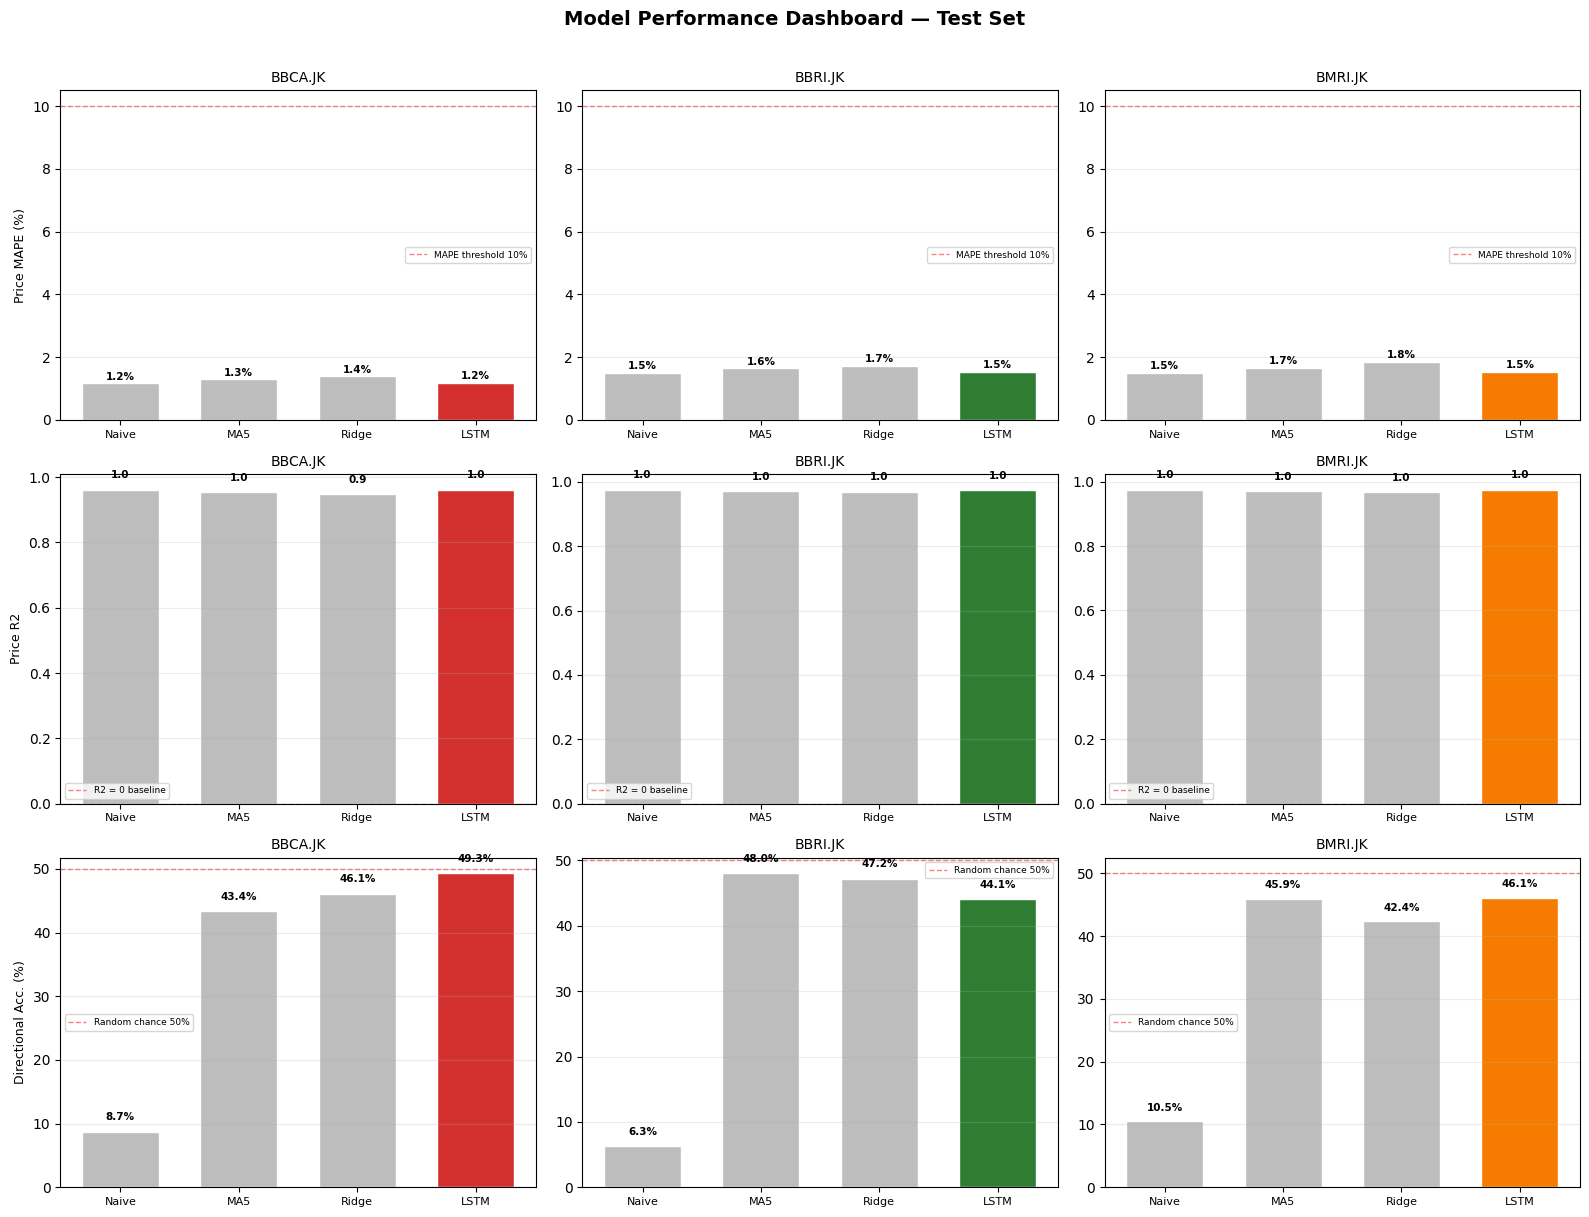

In [33]:
models_to_plot = ['Naive_Zero_Return', 'MA5_Return', 'Ridge_Return', 'LSTM_Return_Ensemble']
model_labels   = ['Naive', 'MA5', 'Ridge', 'LSTM']
metrics_to_show = [
    ('Price_MAPE',         'Price MAPE (%)',       'RdYlGn_r', False, 10,   'MAPE threshold 10%'),
    ('Price_R2',           'Price R2',             'RdYlGn',   True,  0,    'R2 = 0 baseline'),
    ('Direction_Accuracy', 'Directional Acc. (%)', 'RdYlGn',   True,  50,   'Random chance 50%'),
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Model Performance Dashboard — Test Set', fontsize=14, fontweight='bold', y=1.01)

for row, (metric, ylabel, cmap, higher_better, ref_line, ref_label) in enumerate(metrics_to_show):
    for col, ticker in enumerate(TICKERS):
        ax = axes[row][col]
        ticker_data = metrics_all[
            (metrics_all['Ticker'] == ticker) & (metrics_all['Split'] == 'Test')
        ].set_index('Model')

        vals = [ticker_data.loc[m, metric] if m in ticker_data.index else np.nan for m in models_to_plot]
        bar_colors = ['#BDBDBD', '#BDBDBD', '#BDBDBD', TICKER_COLOR[ticker]]
        bars = ax.bar(model_labels, vals, color=bar_colors, edgecolor='white', width=0.65)

        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                fmt = f'{val:.1f}' + ('%' if '%' in ylabel else '')
                offset = max(abs(v) for v in vals if not np.isnan(v)) * 0.03
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + (offset if val >= 0 else -offset * 3),
                        fmt, ha='center', va='bottom', fontsize=7.5, fontweight='bold')

        ax.axhline(ref_line, color='#E53935', lw=1, linestyle='--', alpha=0.6, label=ref_label)
        ax.set_title(f'{ticker}', fontsize=10)
        ax.set_ylabel(ylabel if col == 0 else '', fontsize=9)
        ax.grid(axis='y', alpha=0.25)
        ax.legend(fontsize=6.5)
        ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig(EVAL_DIR / 'performance_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()


## 30-Day Forecast


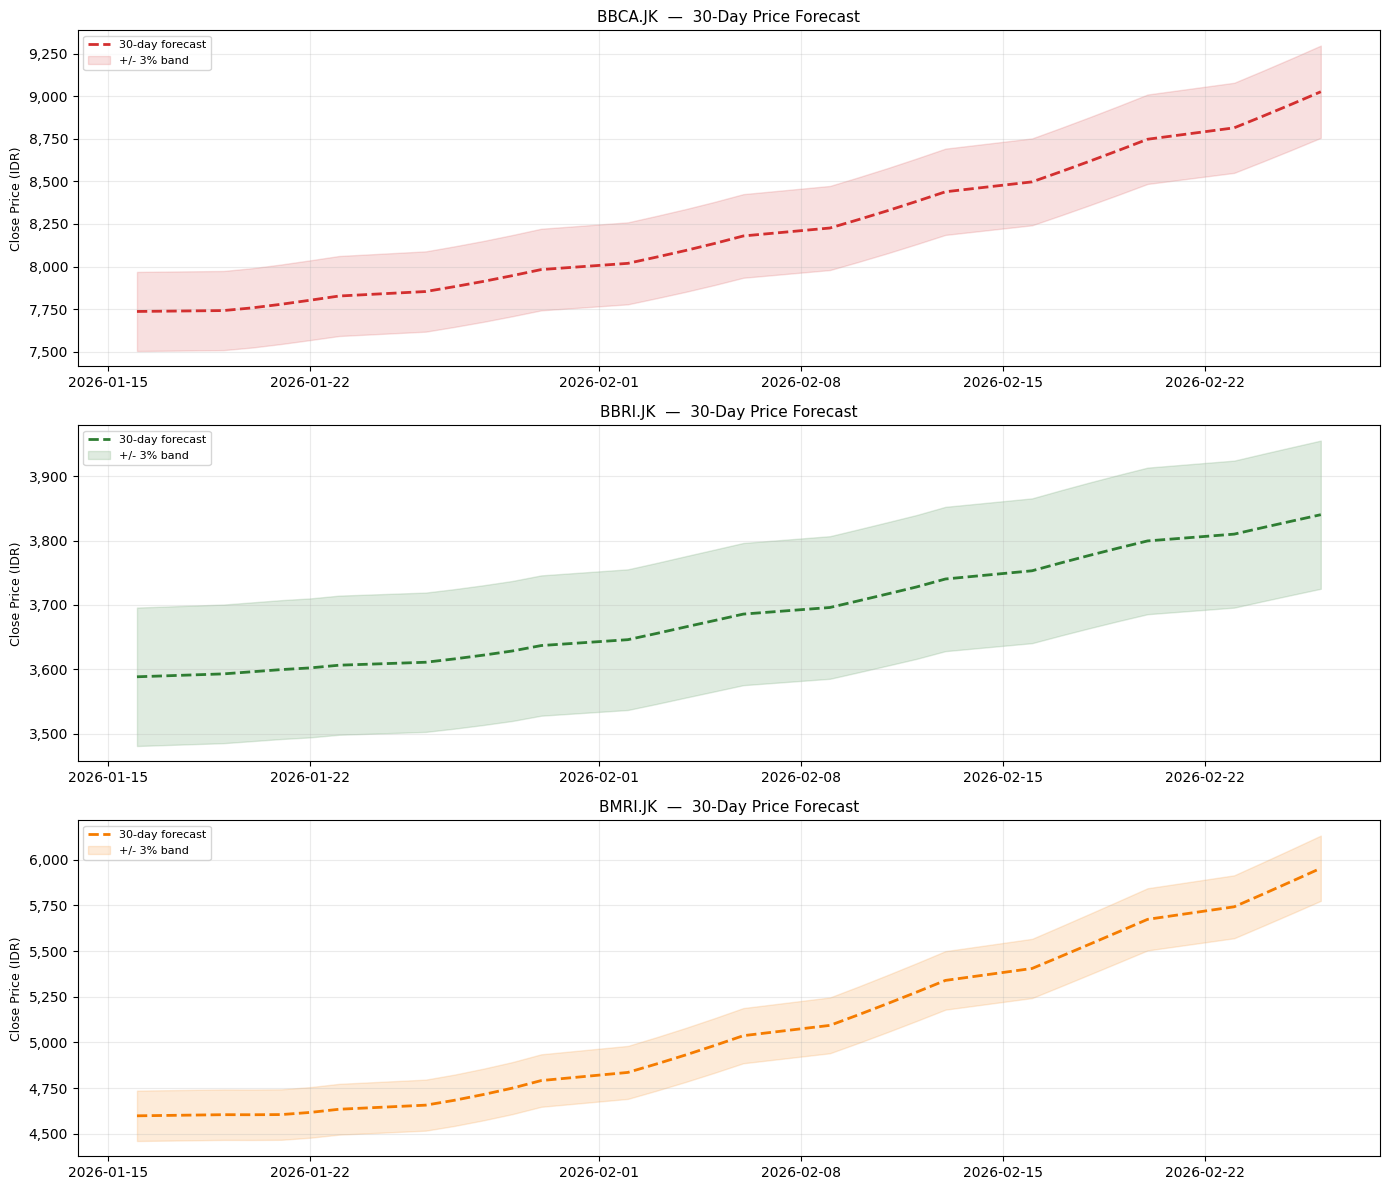

In [34]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, ticker, safe in zip(axes, TICKERS, SAFE_TICKERS):
    fc = forecast_all[ticker].copy()
    fc['Date'] = pd.to_datetime(fc['Date'])

    color = TICKER_COLOR[ticker]
    ax.plot(fc['Date'], fc['Predicted_Close'], color=color, lw=2,
            linestyle='--', label='30-day forecast', zorder=3)
    ax.fill_between(fc['Date'],
                    fc['Predicted_Close'] * 0.97,
                    fc['Predicted_Close'] * 1.03,
                    color=color, alpha=0.15, label='+/- 3% band')
    ax.set_title(f'{ticker}  —  30-Day Price Forecast', fontsize=11)
    ax.set_ylabel('Close Price (IDR)', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(EVAL_DIR / 'forecast_30d_all.png', dpi=130, bbox_inches='tight')
plt.show()


## Summary & Export


In [35]:
summary = lstm_test[['Price_MAPE', 'Price_R2', 'Direction_Accuracy']].copy()
summary['MAPE_Grade']  = summary['Price_MAPE'].apply(
    lambda x: 'Excellent (<= 10%)' if x <= 10 else ('Good (10-20%)' if x <= 20 else 'Fair (> 20%)')
)
summary['Fit_Status']  = fit_df['Fit_Status']
summary['Beats_Naive'] = lstm_accept['Beats_Naive_DA']

display(
    summary.style
    .format({'Price_MAPE': '{:.3f}%', 'Price_R2': '{:.4f}', 'Direction_Accuracy': '{:.2f}%'})
    .background_gradient(subset=['Price_MAPE'], cmap='RdYlGn_r')
    .background_gradient(subset=['Price_R2', 'Direction_Accuracy'], cmap='RdYlGn')
    .set_caption('Final Evaluation Summary')
)

out_path = ROOT / 'reports' / 'evaluation' / 'evaluation_summary.csv'
summary.to_csv(out_path)
print('Saved:', out_path)


,Price_MAPE,Price_R2,Direction_Accuracy,MAPE_Grade,Fit_Status,Beats_Naive
Ticker,,,,,,
BBCA.JK,1.183%,0.9615,49.31%,Excellent (<= 10%),Good Fit,True
BBRI.JK,1.530%,0.9747,44.07%,Excellent (<= 10%),Good Fit,True
BMRI.JK,1.521%,0.9746,46.14%,Excellent (<= 10%),Good Fit,True


Saved: c:\Users\akbar\VSCode Project\RaksaDana\reports\evaluation\evaluation_summary.csv
